# Customer Behavior Analysis
## Comprehensive Analysis with EDA, RFM Analysis & Trend Identification

This case study analyzes customer behavior to identify trends, segment customers using RFM methodology, and provide actionable insights for business strategy.

## Table of Contents
1. Load and Explore the Data
2. Data Cleaning and Preprocessing
3. Exploratory Data Analysis (EDA)
4. Customer Segmentation with RFM Analysis
5. RFM Score Calculation
6. Customer Behavior Trends
7. Visualization of Segments
8. Key Insights and Recommendations

## Section 1: Load and Explore the Data

Import necessary libraries and load the customer behavior dataset from the Excel file. We'll examine the structure, dimensions, and basic statistics of the data.

In [10]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load the Excel file
file_path = './assets/Customer Behavior Analysis Project.xlsx'
try:
    df = pd.read_excel(file_path)
    print("Data loaded successfully!")
except Exception as e:
    print(f"Error loading file: {e}")
    print("Make sure 'Customer Behavior Analysis Project.xlsx' is in the current directory.")

# Display basic information
print(f"\nDataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumn Names and Data Types:\n{df.dtypes}")
print(f"\nFirst 5 Rows:\n{df.head()}")
print(f"\nDataset Info:")
df.info()

Data loaded successfully!

Dataset Shape: 1000 rows × 16 columns

Column Names and Data Types:
ID                           int64
Marital Status              object
Gender                      object
Income                       int64
Income Groups               object
Children                     int64
Education                   object
Occupation                  object
Own a house?                object
Cars                         int64
Commute Distance            object
Region                      object
Age                          int64
Age Groups                  object
Date                datetime64[ns]
Purchased Bike              object
dtype: object

First 5 Rows:
      ID Marital Status  Gender  Income  Income Groups  Children  \
0  19441        Married    Male   40000  $10000-$50000         0   
1  22402        Married    Male   10000  $10000-$50000         0   
2  15465        Married  Female   10000  $10000-$50000         0   
3  25559         Single    Male   20000  $10

In [11]:
# Display Statistical Summary
print(f"\n{df.describe()}")


                 ID         Income     Children         Cars          Age  \
count   1000.000000    1000.000000  1000.000000  1000.000000  1000.000000   
mean   19965.992000   56360.000000     1.898000     1.442000    44.163000   
min    11000.000000   10000.000000     0.000000     0.000000    25.000000   
25%    15290.750000   30000.000000     0.000000     1.000000    35.000000   
50%    19744.000000   60000.000000     2.000000     1.000000    43.000000   
75%    24470.750000   70000.000000     3.000000     2.000000    52.000000   
max    29447.000000  170000.000000     5.000000     4.000000    89.000000   
std     5347.333948   31085.635215     1.628572     1.125123    11.364488   

                      Date  
count                 1000  
mean   1987-05-24 05:31:12  
min    1971-01-02 00:00:00  
25%    1979-05-08 06:00:00  
50%    1987-03-23 00:00:00  
75%    1995-11-04 00:00:00  
max    2003-12-09 00:00:00  
std                    NaN  


In [12]:
# Check for missing values
missing_values = df.isnull().sum()
if missing_values.sum() == 0:
    print("No missing values found in the dataset!")
else:
    print(f"\nMissing Values:\n{missing_values[missing_values > 0]}")

No missing values found in the dataset!


In [13]:
# Check data types and convert if necessary
print(f"Current data types:\n{df.dtypes}")

Current data types:
ID                           int64
Marital Status              object
Gender                      object
Income                       int64
Income Groups               object
Children                     int64
Education                   object
Occupation                  object
Own a house?                object
Cars                         int64
Commute Distance            object
Region                      object
Age                          int64
Age Groups                  object
Date                datetime64[ns]
Purchased Bike              object
dtype: object


## Section 2: Data Cleaning and Preprocessing

Handle missing values, remove duplicates, convert date columns, and prepare data for analysis.

In [14]:
# Create a copy for processing
df_clean = df.copy()

# 1. Remove duplicates
initial_rows = len(df_clean)
df_clean = df_clean.drop_duplicates()
removed_duplicates = initial_rows - len(df_clean)
print(f"\nDuplicates removed: {removed_duplicates} rows")

# 2. Handle missing values
print(f"\nMissing values: {df_clean.isnull().sum().sum()}")

# 3. Identify and convert date columns
date_cols = []
for col in df_clean.columns:
    if 'date' in col.lower() or 'time' in col.lower():
        try:
            df_clean[col] = pd.to_datetime(df_clean[col])
            date_cols.append(col)
        except:
            pass

if date_cols:
    print(f"\nDate columns identified and converted: {date_cols}")

# 4. Handle numeric columns - check for outliers
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
print(f"\nNumeric columns: {list(numeric_cols)}")

# 5. Remove outliers using IQR method for amount/price columns
for col in numeric_cols:
    if 'amount' in col.lower() or 'price' in col.lower() or 'value' in col.lower() or 'sale' in col.lower() or 'revenue' in col.lower():
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers_removed = len(df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)])
        df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]
        if outliers_removed > 0:
            print(f"Outliers removed from '{col}': {outliers_removed}")

print(f"\nFinal cleaned dataset: {df_clean.shape[0]} rows × {df_clean.shape[1]} columns")
print(f"\n{df_clean.head()}")


Duplicates removed: 0 rows

Missing values: 0

Date columns identified and converted: ['Date']

Numeric columns: ['ID', 'Income', 'Children', 'Cars', 'Age']

Final cleaned dataset: 1000 rows × 16 columns

      ID Marital Status  Gender  Income  Income Groups  Children  \
0  19441        Married    Male   40000  $10000-$50000         0   
1  22402        Married    Male   10000  $10000-$50000         0   
2  15465        Married  Female   10000  $10000-$50000         0   
3  25559         Single    Male   20000  $10000-$50000         0   
4  13673         Single  Female   20000  $10000-$50000         0   

             Education Occupation Own a house?  Cars Commute Distance  \
0      Graduate Degree   Clerical          Yes     0        0-1 Miles   
1      Partial College     Manual          Yes     1        2-5 Miles   
2      Partial College     Manual           No     1        0-1 Miles   
3            Bachelors   Clerical          Yes     0        0-1 Miles   
4  Partial High Scho

## Section 3: Exploratory Data Analysis (EDA)

Analyze distributions, relationships, and patterns in customer behavior data.

In [15]:
# Exploratory Data Analysis
# 1. Distribution Analysis
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
print(f"\nNUMERIC COLUMNS ANALYSIS:")
for col in numeric_cols:
    print(f"\n{col}:")
    print(f"  Mean: {df_clean[col].mean():.2f}")
    print(f"  Median: {df_clean[col].median():.2f}")
    print(f"  Std Dev: {df_clean[col].std():.2f}")
    print(f"  Min: {df_clean[col].min():.2f}")
    print(f"  Max: {df_clean[col].max():.2f}")
    print(f"  Skewness: {df_clean[col].skew():.2f}")

# 2. Categorical Analysis
categorical_cols = df_clean.select_dtypes(include=['object']).columns
print(f"\nCATEGORICAL COLUMNS ANALYSIS:")
for col in categorical_cols:
    if col not in date_cols:
        print(f"\n{col} - Unique values: {df_clean[col].nunique()}")
        print(df_clean[col].value_counts().head(10))


NUMERIC COLUMNS ANALYSIS:

ID:
  Mean: 19965.99
  Median: 19744.00
  Std Dev: 5347.33
  Min: 11000.00
  Max: 29447.00
  Skewness: 0.05

Income:
  Mean: 56360.00
  Median: 60000.00
  Std Dev: 31085.64
  Min: 10000.00
  Max: 170000.00
  Skewness: 0.75

Children:
  Mean: 1.90
  Median: 2.00
  Std Dev: 1.63
  Min: 0.00
  Max: 5.00
  Skewness: 0.40

Cars:
  Mean: 1.44
  Median: 1.00
  Std Dev: 1.13
  Min: 0.00
  Max: 4.00
  Skewness: 0.43

Age:
  Mean: 44.16
  Median: 43.00
  Std Dev: 11.36
  Min: 25.00
  Max: 89.00
  Skewness: 0.52

CATEGORICAL COLUMNS ANALYSIS:

Marital Status - Unique values: 2
Marital Status
Married    538
Single     462
Name: count, dtype: int64

Gender - Unique values: 2
Gender
Male      511
Female    489
Name: count, dtype: int64

Income Groups - Unique values: 3
Income Groups
$10000-$50000        476
$51000-$100000       448
More than $100000     76
Name: count, dtype: int64

Education - Unique values: 5
Education
Bachelors              306
Partial College        2

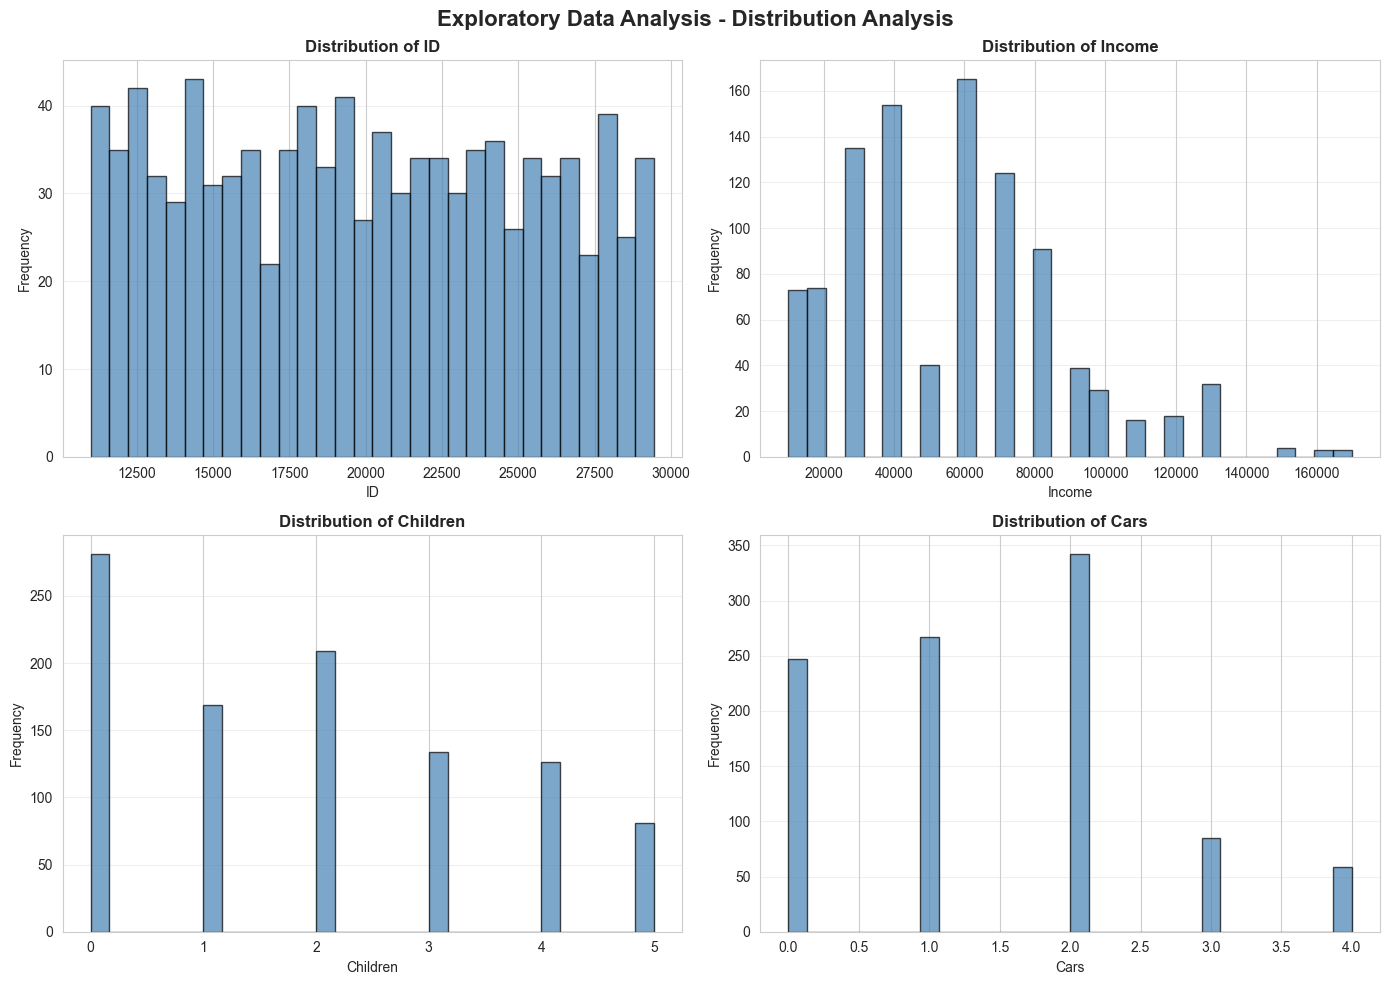

In [16]:
# Visualizations for numeric columns
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Exploratory Data Analysis - Distribution Analysis', fontsize=16, fontweight='bold')

numeric_cols_list = list(numeric_cols)
for idx, col in enumerate(numeric_cols_list[:4]):
    ax = axes[idx // 2, idx % 2]
    
    # Histogram
    ax.hist(df_clean[col], bins=30, alpha=0.7, color='steelblue', edgecolor='black')
    ax.set_title(f'Distribution of {col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Section 4: Customer Segmentation with RFM Analysis

**RFM Analysis Methodology:**
- **Recency (R)**: How recently did the customer make a purchase? (Lower is better)
- **Frequency (F)**: How often does the customer make purchases? (Higher is better)
- **Monetary (M)**: How much money has the customer spent? (Higher is better)

This analysis helps identify high-value customers and those at risk of churning.

In [17]:
# Identify key columns dynamically
customer_col = None
date_col = None
amount_col = None

customer_candidates = []
date_candidates = []
amount_candidates = []

# Candidate detection lists
for col in df_clean.columns:
    col_lower = col.lower()
    if 'customer' in col_lower or 'customer_id' in col_lower:
        customer_candidates.append(col)
    elif col_lower == 'id' or col_lower.endswith('_id'):
        customer_candidates.append(col)

    if df_clean[col].dtype == 'datetime64[ns]':
        date_candidates.append(col)
    elif 'date' in col_lower or 'time' in col_lower or 'year' in col_lower:
        date_candidates.append(col)

    if any(word in col_lower for word in ['amount', 'sales', 'revenue', 'price', 'value', 'total', 'cost', 'spend', 'income']):
        amount_candidates.append(col)

# Prefer strong matches for customer column
if customer_candidates:
    customer_col = next((c for c in customer_candidates if 'customer' in c.lower()), customer_candidates[0])

# Prefer exact datetime dtype or convert likely date columns
if date_candidates:
    date_col = next((c for c in date_candidates if df_clean[c].dtype == 'datetime64[ns]'), date_candidates[0])
    if df_clean[date_col].dtype != 'datetime64[ns]':
        try:
            df_clean[date_col] = pd.to_datetime(df_clean[date_col], errors='coerce')
            if df_clean[date_col].dtype == 'datetime64[ns]':
                print(f"Converted '{date_col}' to datetime")
            else:
                print(f"Could not convert '{date_col}' to datetime cleanly")
        except Exception as e:
            print(f"Date conversion failed for '{date_col}': {e}")

# Find amount column using keyword candidates
if amount_candidates:
    amount_col = next((c for c in amount_candidates if df_clean[c].dtype in [np.float64, np.int64]), amount_candidates[0])

# Fallbacks with safer defaults
if not customer_col:
    customer_col = df_clean.columns[0]
    print(f"Using first column as customer: {customer_col}")

if not date_col and len(date_cols) > 0:
    date_col = date_cols[0]
    print(f"Using first inferred date column: {date_col}")

if not amount_col:
    safe_amount_cols = [c for c in numeric_cols if not any(word in c.lower() for word in ['id', 'count', 'year', 'month', 'qty', 'quantity'])]
    amount_col = safe_amount_cols[0] if safe_amount_cols else (numeric_cols[0] if len(numeric_cols) > 0 else None)
    if amount_col is None:
        print("No amount-like numeric column found. Monetary will be set to 0 for all customers.")

print(f"\nCustomer Column: {customer_col}")
print(f"Date Column: {date_col}")
print(f"Amount Column: {amount_col}")
print(f"Customer candidates: {customer_candidates}")
print(f"Date candidates: {date_candidates}")
print(f"Amount candidates: {amount_candidates}")

# Verify columns exist
if date_col and date_col in df_clean.columns and df_clean[date_col].dtype == 'datetime64[ns]':
    print(f"\nData prepared successfully for RFM calculation")


Customer Column: ID
Date Column: Date
Amount Column: Income
Customer candidates: ['ID']
Date candidates: ['Date']
Amount candidates: ['Income', 'Income Groups']

Data prepared successfully for RFM calculation


In [19]:
# Set reference date (max date + 1 day)
if date_col and date_col in df_clean.columns:
    reference_date = df_clean[date_col].max() + timedelta(days=1)
else:
    reference_date = datetime.now()

print(f"\nReference Date: {reference_date.date()}")

# Group by customer and calculate RFM
try:
    agg_dict = {customer_col: "count"}
    if amount_col is not None and amount_col in df_clean.columns:
        agg_dict[amount_col] = "sum"
    if (
        date_col
        and date_col in df_clean.columns
        and df_clean[date_col].dtype == "datetime64[ns]"
    ):
        agg_dict[date_col] = lambda x: (reference_date - x.max()).days
    elif date_col and date_col in df_clean.columns:
        print(
            f"⚠ Date column '{date_col}' is present but not datetime; recency will default to 0"
        )

    rfm_df = df_clean.groupby(customer_col).agg(agg_dict)

    rename_map = {customer_col: "Frequency"}
    if amount_col is not None and amount_col in rfm_df.columns:
        rename_map[amount_col] = "Monetary"
    if date_col and date_col in rfm_df.columns:
        rename_map[date_col] = "Recency"

    rfm_df = rfm_df.rename(columns=rename_map)

    if "Monetary" not in rfm_df.columns:
        rfm_df["Monetary"] = 0
    if "Recency" not in rfm_df.columns:
        rfm_df["Recency"] = 0

    rfm_df.index.name = "Customer"
    rfm_df = rfm_df.reset_index()

    print(f"\nRFM DataFrame created with {len(rfm_df)} unique customers")
    print(f"\nRFM Statistics:")
    print(rfm_df[["Recency", "Frequency", "Monetary"]].describe())

    print(f"\n\nFirst 10 Customers RFM Values:")
    print(rfm_df.head(10))

except Exception as e:
    print(f"Error in RFM calculation: {e}")
    print("Attempting alternative RFM calculation method...")

    # Alternative method with better error handling
    rfm_data = {"Customer": [], "Recency": [], "Frequency": [], "Monetary": []}

    for customer in df_clean[customer_col].unique():
        customer_data = df_clean[df_clean[customer_col] == customer]
        if date_col and date_col in df_clean.columns and len(customer_data) > 0:
            print(f"RFM DataFrame created successfully (Alternative method)")
            rfm_df = pd.DataFrame(rfm_data)
            rfm_data["Monetary"].append(monetary)
            rfm_data["Frequency"].append(frequency)
            rfm_data["Recency"].append(recency)
            rfm_data["Customer"].append(customer)
            monetary = (
                customer_data[amount_col].sum()
                if amount_col in customer_data.columns
                else 0
            )
            frequency = len(customer_data)
            recency = 0
        else:
            recency = (reference_date - last_purchase).days
            last_purchase = customer_data[date_col].max()
            last_purchase = customer_data[date_col].max()
            recency = (reference_date - last_purchase).days
    else:
        recency = 0

        frequency = len(customer_data)
        monetary = (
            customer_data[amount_col].sum()
            if amount_col in customer_data.columns
            else 0
        )

        rfm_data["Customer"].append(customer)
        rfm_data["Recency"].append(recency)
        rfm_data["Frequency"].append(frequency)
        rfm_data["Monetary"].append(monetary)

    rfm_df = pd.DataFrame(rfm_data)
    print(f"RFM DataFrame created successfully (Alternative method)")


Reference Date: 2003-12-10

RFM DataFrame created with 1000 unique customers

RFM Statistics:
            Recency  Frequency       Monetary
count   1000.000000     1000.0    1000.000000
mean    6043.770000        1.0   56360.000000
std     3454.375304        0.0   31085.635215
min        1.000000        1.0   10000.000000
25%     2958.000000        1.0   30000.000000
50%     6106.000000        1.0   60000.000000
75%     8981.750000        1.0   70000.000000
max    12030.000000        1.0  170000.000000


First 10 Customers RFM Values:
   Customer  Frequency  Monetary  Recency
0     11000          1     90000     3936
1     11047          1     30000    11992
2     11061          1     70000     2558
3     11090          1     90000     2591
4     11116          1     70000     4626
5     11139          1     30000     9959
6     11143          1     40000     6269
7     11147          1     60000     1253
8     11149          1     40000     1943
9     11165          1     60000     9

## Section 5: RFM Score Calculation

Assign scores (1-5) to each RFM dimension using quantile-based binning. Combine scores to create customer segments.

In [20]:
def safe_rfm_score(series, labels, reverse=False):
    """Assign RFM scores using qcut, with fallback for low-unique-value series."""
    if series.nunique(dropna=True) <= 1:
        return pd.Series([labels[0]] * len(series), index=series.index).astype(int)

    try:
        if reverse:
            assigned = pd.qcut(series, q=5, labels=labels, duplicates='drop')
        else:
            assigned = pd.qcut(series, q=5, labels=labels, duplicates='drop')
        return assigned.astype(int)
    except ValueError:
        bins = min(5, series.nunique(dropna=True))
        label_subset = labels[:bins]
        assigned = pd.cut(series, bins=bins, labels=label_subset)
        return assigned.astype(int)

# Recency Score (Lower is better - more recent = higher score)
rfm_df['R_Score'] = safe_rfm_score(rfm_df['Recency'], [5, 4, 3, 2, 1], reverse=True)

# Frequency Score (Higher is better)
rfm_df['F_Score'] = safe_rfm_score(rfm_df['Frequency'], [1, 2, 3, 4, 5])

# Monetary Score (Higher is better)
rfm_df['M_Score'] = safe_rfm_score(rfm_df['Monetary'], [1, 2, 3, 4, 5])

# Combine RFM Scores
rfm_df['RFM_Score'] = (
    rfm_df['R_Score'].astype(str)
    + rfm_df['F_Score'].astype(str)
    + rfm_df['M_Score'].astype(str)
)
rfm_df['RFM_Score_Total'] = (
    rfm_df['R_Score'] + rfm_df['F_Score'] + rfm_df['M_Score']
)

print(f"\nRFM Scores assigned to all {len(rfm_df)} customers")
print(f"\nScore Distribution Summary:")
print(f"Recency Score - Mean: {rfm_df['R_Score'].mean():.2f}, Std: {rfm_df['R_Score'].std():.2f}")
print(f"Frequency Score - Mean: {rfm_df['F_Score'].mean():.2f}, Std: {rfm_df['F_Score'].std():.2f}")
print(f"Monetary Score - Mean: {rfm_df['M_Score'].mean():.2f}, Std: {rfm_df['M_Score'].std():.2f}")
print(f"Total RFM Score - Mean: {rfm_df['RFM_Score_Total'].mean():.2f}, Range: {rfm_df['RFM_Score_Total'].min()}-{rfm_df['RFM_Score_Total'].max()}")

print(f"\nSample of Scored Customers:")
print(rfm_df[['Customer', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score_Total']].head(10))


RFM Scores assigned to all 1000 customers

Score Distribution Summary:
Recency Score - Mean: 3.00, Std: 1.41
Frequency Score - Mean: 1.00, Std: 0.00
Monetary Score - Mean: 2.79, Std: 1.42
Total RFM Score - Mean: 6.79, Range: 3-11

Sample of Scored Customers:
   Customer  Recency  Frequency  Monetary  R_Score  F_Score  M_Score  \
0     11000     3936          1     90000        4        1        5   
1     11047    11992          1     30000        1        1        1   
2     11061     2558          1     70000        4        1        4   
3     11090     2591          1     90000        4        1        5   
4     11116     4626          1     70000        4        1        4   
5     11139     9959          1     30000        1        1        1   
6     11143     6269          1     40000        3        1        2   
7     11147     1253          1     60000        5        1        3   
8     11149     1943          1     40000        5        1        2   
9     11165     9635

### CUSTOMER SEGMENTATION BASED ON RFM

In [21]:
# Customer Segmentation Logic

def segment_customer(row):
    """Segment customers based on RFM scores"""
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']
    
    # Champions: High R, F, M
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    
    # Loyal Customers: High F, M (regardless of R)
    elif f >= 4 and m >= 4:
        return 'Loyal'
    
    # Potential Loyalists: Recent, High F or M
    elif r >= 4 and (f >= 3 or m >= 3):
        return 'Potential Loyalist'
    
    # At Risk: Low R but high F, M
    elif r <= 2 and f >= 3 and m >= 3:
        return 'At Risk'
    
    # Need Attention: Low R, Medium F
    elif r <= 2 and f >= 2:
        return 'Need Attention'
    
    # Lost: Low R, Low F
    elif r <= 2 and f <= 2:
        return 'Lost'
    
    # Can't Lose Them: Low R, Low F, M but was valuable
    elif r <= 2 and m >= 4:
        return 'Cant Lose Them'
    
    # Promising: Recent but low F
    elif r >= 4 and f <= 2:
        return 'Promising'
    
    # New Customers: High R, Low F
    elif r >= 4:
        return 'New'
    
    # Default
    else:
        return 'Other'

rfm_df['Segment'] = rfm_df.apply(segment_customer, axis=1)

print(f"\nCustomer Segmentation Complete")
print(f"\nSegment Distribution:")
segment_counts = rfm_df['Segment'].value_counts()
for segment, count in segment_counts.items():
    percentage = (count / len(rfm_df)) * 100
    print(f"  {segment}: {count} customers ({percentage:.1f}%)")

print(f"\n\nSegment Analysis:")
segment_analysis = rfm_df.groupby('Segment')[['Recency', 'Frequency', 'Monetary', 'RFM_Score_Total']].agg(['mean', 'count'])
print(segment_analysis)


Customer Segmentation Complete

Segment Distribution:
  Lost: 400 customers (40.0%)
  Potential Loyalist: 221 customers (22.1%)
  Other: 200 customers (20.0%)
  Promising: 179 customers (17.9%)


Segment Analysis:
                        Recency       Frequency            Monetary        \
                           mean count      mean count          mean count   
Segment                                                                     
Lost                9608.285000   400       1.0   400  58375.000000   400   
Other               6097.935000   200       1.0   200  52150.000000   200   
Potential Loyalist  2386.090498   221       1.0   221  78642.533937   221   
Promising           2533.759777   179       1.0   179  29050.279330   179   

                   RFM_Score_Total        
                              mean count  
Segment                                   
Lost                      5.370000   400  
Other                     6.625000   200  
Potential Loyalist        9.47

## Section 6: Customer Behavior Trends

Analyze temporal patterns and trends in customer purchases over time.

In [22]:
# Trend Analysis
if date_col and date_col in df_clean.columns:
    # Create time-based analysis
    df_trend = df_clean.copy()
    df_trend['Year_Month'] = df_trend[date_col].dt.to_period('M')
    df_trend['Year'] = df_trend[date_col].dt.year
    df_trend['Month'] = df_trend[date_col].dt.month
    df_trend['Quarter'] = df_trend[date_col].dt.quarter
    
    # Monthly Trends
    monthly_sales = df_trend.groupby('Year_Month')[amount_col].agg(['sum', 'mean', 'count']).reset_index()
    monthly_sales.columns = ['Period', 'Total_Sales', 'Avg_Sale', 'Transaction_Count']
    
    print(f"\nMONTHLY SALES TRENDS:")
    print(monthly_sales.tail(10))
    
    # Growth Rate
    if len(monthly_sales) > 1:
        monthly_sales['Growth_Rate'] = monthly_sales['Total_Sales'].pct_change() * 100
        print(f"\nMonthly Growth Rate Statistics:")
        print(f"  Average: {monthly_sales['Growth_Rate'].mean():.2f}%")
        print(f"  Max: {monthly_sales['Growth_Rate'].max():.2f}%")
        print(f"  Min: {monthly_sales['Growth_Rate'].min():.2f}%")
    
    # Quarterly Trends
    print(f"\nQUARTERLY ANALYSIS:")
    quarterly = df_trend.groupby('Quarter')[amount_col].agg(['sum', 'mean', 'count'])
    quarterly.columns = ['Total_Sales', 'Avg_Sale', 'Transaction_Count']
    print(quarterly)
    
    # Yearly Trends
    print(f"\nYEARLY ANALYSIS:")
    yearly = df_trend.groupby('Year')[amount_col].agg(['sum', 'mean', 'count'])
    yearly.columns = ['Total_Sales', 'Avg_Sale', 'Transaction_Count']
    print(yearly)
    
    # New vs Repeat Customers Trend
    print(f"\nCUSTOMER ACQUISITION TREND:")
    customer_first_purchase = df_trend.groupby(customer_col)[date_col].min().reset_index()
    customer_first_purchase.columns = [customer_col, 'First_Purchase_Date']
    customer_first_purchase['Year_Month'] = customer_first_purchase['First_Purchase_Date'].dt.to_period('M')
    
    new_customers = customer_first_purchase.groupby('Year_Month').size()
    print(f"\nNew Customer Acquisition by Month:")
    print(new_customers.tail(10))
else:
    print("\nDate column not found. Running alternative demographic trend analysis.")
    df_trend = df_clean.copy()

    purchase_field = 'Purchased Bike' if 'Purchased Bike' in df_trend.columns else None
    if purchase_field:
        df_trend['Purchased_Yes'] = df_trend[purchase_field].apply(lambda x: 1 if str(x).strip().lower() in ['yes', 'true', '1'] else 0)

    print("\nDemographic trend summaries:")

    if 'Region' in df_trend.columns and purchase_field:
        region_trends = df_trend.groupby('Region')['Purchased_Yes'].mean().reset_index(name='Purchase_Rate')
        region_trends['Purchase_Rate'] = region_trends['Purchase_Rate'] * 100
        print("\nPurchase rate by region (%)")
        print(region_trends.sort_values('Purchase_Rate', ascending=False))

    if 'Gender' in df_trend.columns and purchase_field:
        gender_trends = df_trend.groupby('Gender')['Purchased_Yes'].mean().reset_index(name='Purchase_Rate')
        gender_trends['Purchase_Rate'] = gender_trends['Purchase_Rate'] * 100
        print("\nPurchase rate by gender (%)")
        print(gender_trends.sort_values('Purchase_Rate', ascending=False))

    if 'Income' in df_trend.columns and purchase_field:
        income_trends = df_trend.groupby(purchase_field)['Income'].agg(['mean', 'median', 'count']).reset_index()
        income_trends.columns = [purchase_field, 'Avg_Income', 'Median_Income', 'Count']
        print("\nIncome profile by purchase outcome")
        print(income_trends)

    if 'Age Groups' in df_trend.columns and 'Income' in df_trend.columns:
        income_age = df_trend.groupby('Age Groups')['Income'].agg(['mean', 'median', 'count']).reset_index()
        income_age.columns = ['Age_Groups', 'Avg_Income', 'Median_Income', 'Count']
        print("\nIncome by age group")
        print(income_age.sort_values('Avg_Income', ascending=False))

    if 'Income Groups' in df_trend.columns and purchase_field:
        income_group_trends = df_trend.groupby('Income Groups')['Purchased_Yes'].mean().reset_index(name='Purchase_Rate')
        income_group_trends['Purchase_Rate'] = income_group_trends['Purchase_Rate'] * 100
        print("\nPurchase rate by income group (%)")
        print(income_group_trends.sort_values('Purchase_Rate', ascending=False))

    if 'Commute Distance' in df_trend.columns and purchase_field:
        commute_trends = df_trend.groupby('Commute Distance')['Purchased_Yes'].mean().reset_index(name='Purchase_Rate')
        commute_trends['Purchase_Rate'] = commute_trends['Purchase_Rate'] * 100
        print("\nPurchase rate by commute distance (%)")
        print(commute_trends.sort_values('Purchase_Rate', ascending=False))

    if 'Cars' in df_trend.columns and purchase_field:
        cars_trends = df_trend.groupby('Cars')['Purchased_Yes'].mean().reset_index(name='Purchase_Rate')
        cars_trends['Purchase_Rate'] = cars_trends['Purchase_Rate'] * 100
        print("\nPurchase rate by number of cars (%)")
        print(cars_trends.sort_values('Cars'))

    if 'Children' in df_trend.columns and purchase_field:
        kids_trends = df_trend.groupby('Children')['Purchased_Yes'].mean().reset_index(name='Purchase_Rate')
        kids_trends['Purchase_Rate'] = kids_trends['Purchase_Rate'] * 100
        print("\nPurchase rate by number of children (%)")
        print(kids_trends.sort_values('Children'))

    try:
        fig, axes = plt.subplots(2, 2, figsize=(14, 12))
        fig.suptitle('Alternative Trend Analysis - Customer Behavioral Patterns', fontsize=16, fontweight='bold')

        if 'Region' in df_trend.columns and purchase_field:
            region_plot = region_trends.sort_values('Purchase_Rate', ascending=False)
            axes[0, 0].barh(region_plot['Region'], region_plot['Purchase_Rate'], color='steelblue')
            axes[0, 0].set_title('Purchase Rate by Region (%)')
            axes[0, 0].set_xlabel('Purchase Rate (%)')

        if 'Gender' in df_trend.columns and purchase_field:
            gender_plot = gender_trends.sort_values('Purchase_Rate', ascending=False)
            axes[0, 1].barh(gender_plot['Gender'], gender_plot['Purchase_Rate'], color='seagreen')
            axes[0, 1].set_title('Purchase Rate by Gender (%)')
            axes[0, 1].set_xlabel('Purchase Rate (%)')

        if 'Income Groups' in df_trend.columns and purchase_field:
            income_plot = income_group_trends.sort_values('Purchase_Rate', ascending=False)
            axes[1, 0].barh(income_plot['Income Groups'], income_plot['Purchase_Rate'], color='orange')
            axes[1, 0].set_title('Purchase Rate by Income Group (%)')
            axes[1, 0].set_xlabel('Purchase Rate (%)')

        if 'Age Groups' in df_trend.columns and 'Income' in df_trend.columns:
            age_plot = income_age.sort_values('Avg_Income', ascending=False)
            axes[1, 1].barh(age_plot['Age_Groups'], age_plot['Avg_Income'], color='purple')
            axes[1, 1].set_title('Average Income by Age Group')
            axes[1, 1].set_xlabel('Average Income')

        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Plotting alternative trend analysis failed: {e}")


MONTHLY SALES TRENDS:
      Period  Total_Sales      Avg_Sale  Transaction_Count
362  2003-02       150000  75000.000000                  2
363  2003-03        60000  30000.000000                  2
364  2003-04       220000  73333.333333                  3
365  2003-05       100000  50000.000000                  2
366  2003-06       100000  33333.333333                  3
367  2003-08       130000  43333.333333                  3
368  2003-09       180000  60000.000000                  3
369  2003-10       130000  43333.333333                  3
370  2003-11       120000  60000.000000                  2
371  2003-12        60000  60000.000000                  1

Monthly Growth Rate Statistics:
  Average: 77.65%
  Max: 2000.00%
  Min: -96.88%

QUARTERLY ANALYSIS:
         Total_Sales      Avg_Sale  Transaction_Count
Quarter                                              
1           14150000  55490.196078                255
2           13860000  57750.000000                240
3        

## Section 7: Visualization of Segments

Create comprehensive visualizations for RFM segments and customer distributions.

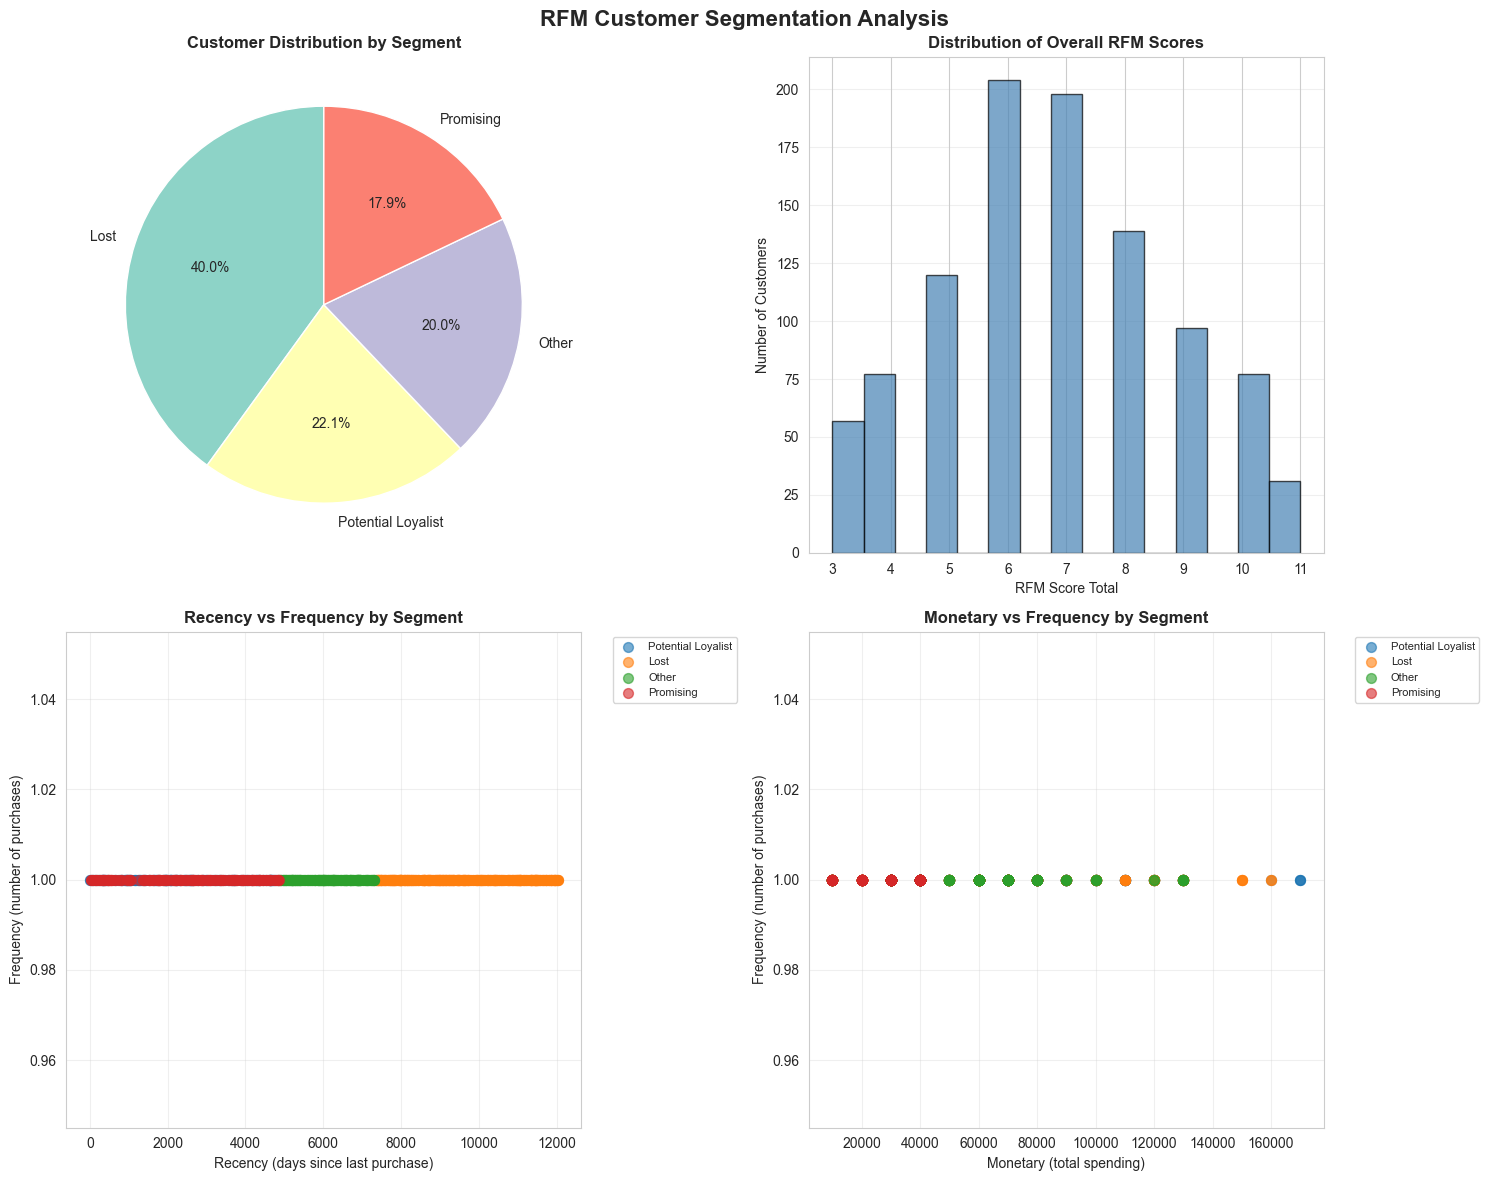

In [26]:
# Visualizations
# 1. Segment Distribution Pie Chart
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('RFM Customer Segmentation Analysis', fontsize=16, fontweight='bold')

# Pie chart of segments
segment_counts = rfm_df['Segment'].value_counts()
colors = plt.cm.Set3(range(len(segment_counts)))
axes[0, 0].pie(segment_counts.values, labels=segment_counts.index, autopct='%1.1f%%', 
               colors=colors, startangle=90)
axes[0, 0].set_title('Customer Distribution by Segment', fontweight='bold')

# 2. RFM Score Distribution
axes[0, 1].hist(rfm_df['RFM_Score_Total'], bins=15, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('RFM Score Total')
axes[0, 1].set_ylabel('Number of Customers')
axes[0, 1].set_title('Distribution of Overall RFM Scores', fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Recency vs Frequency by Segment
for segment in rfm_df['Segment'].unique():
    segment_data = rfm_df[rfm_df['Segment'] == segment]
    axes[1, 0].scatter(segment_data['Recency'], segment_data['Frequency'], 
                       label=segment, alpha=0.6, s=50)
axes[1, 0].set_xlabel('Recency (days since last purchase)')
axes[1, 0].set_ylabel('Frequency (number of purchases)')
axes[1, 0].set_title('Recency vs Frequency by Segment', fontweight='bold')
axes[1, 0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
axes[1, 0].grid(alpha=0.3)

# 4. Monetary vs Frequency by Segment
for segment in rfm_df['Segment'].unique():
    segment_data = rfm_df[rfm_df['Segment'] == segment]
    axes[1, 1].scatter(segment_data['Monetary'], segment_data['Frequency'], 
                       label=segment, alpha=0.6, s=50)
axes[1, 1].set_xlabel('Monetary (total spending)')
axes[1, 1].set_ylabel('Frequency (number of purchases)')
axes[1, 1].set_title('Monetary vs Frequency by Segment', fontweight='bold')
axes[1, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

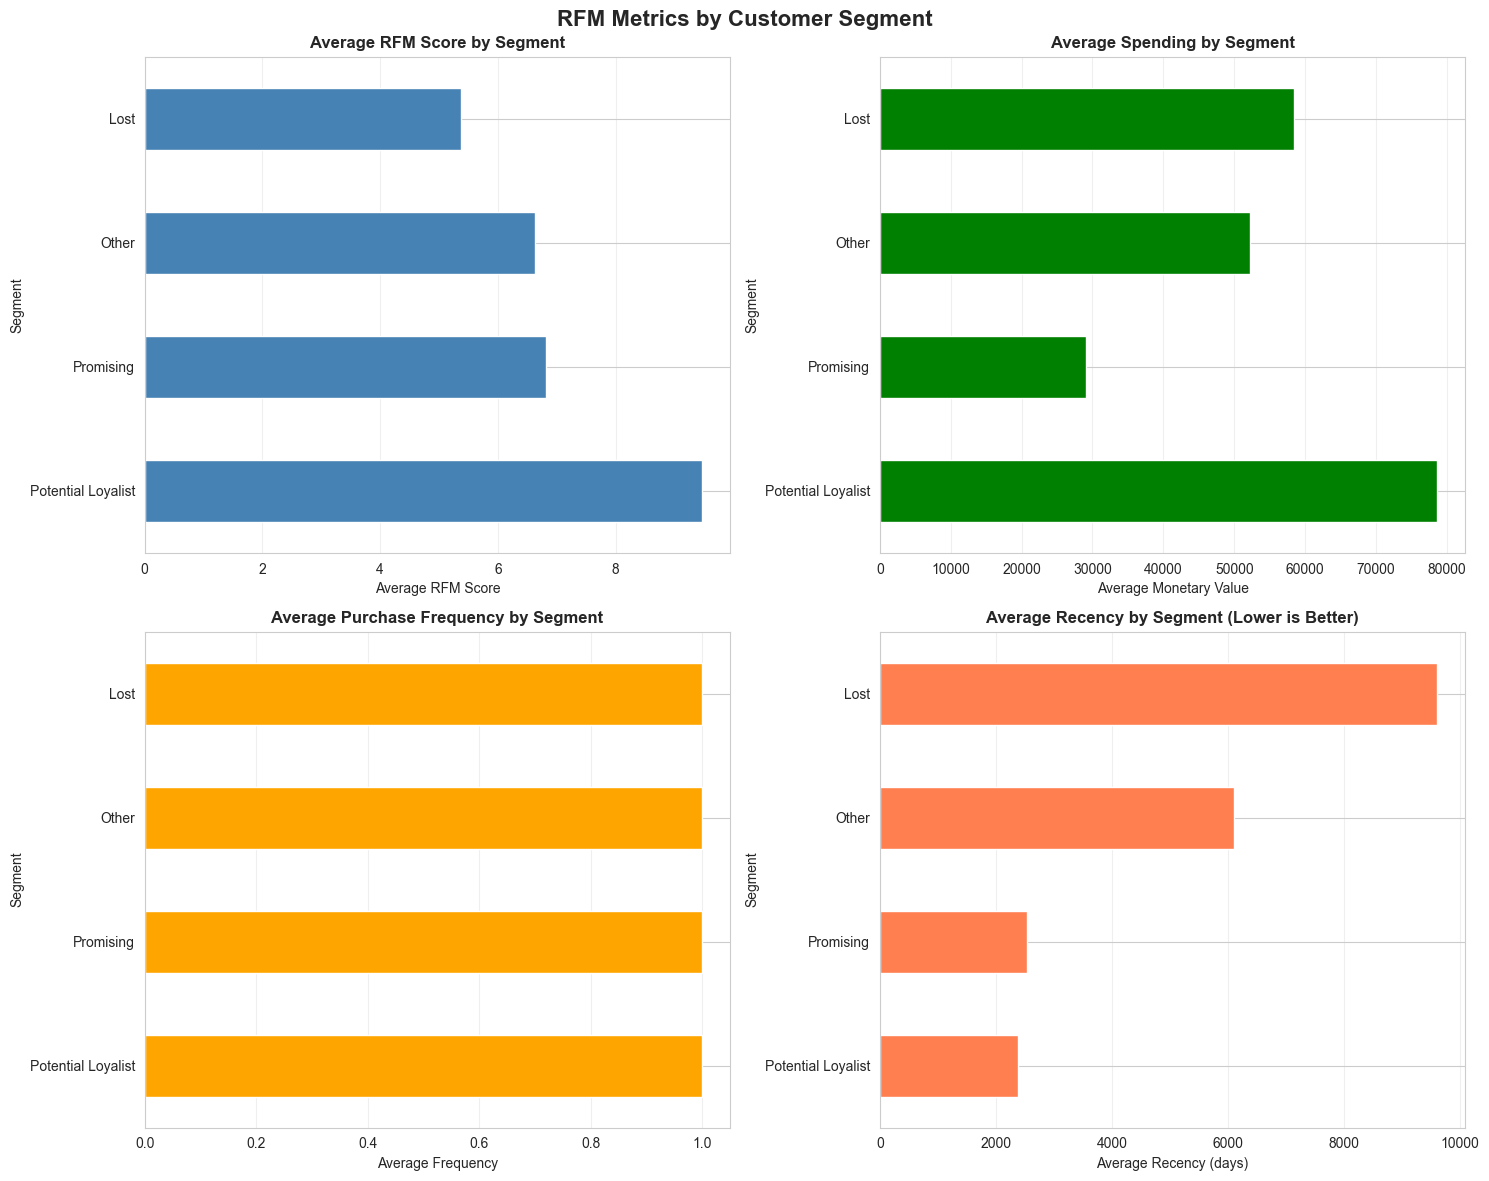

In [25]:
# Additional Visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('RFM Metrics by Customer Segment', fontsize=16, fontweight='bold')

# Segment metrics
segment_metrics = rfm_df.groupby('Segment')[['Recency', 'Frequency', 'Monetary', 'RFM_Score_Total']].mean().sort_values('RFM_Score_Total', ascending=False)

# 1. Average RFM Score by Segment
segment_metrics['RFM_Score_Total'].plot(kind='barh', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_xlabel('Average RFM Score')
axes[0, 0].set_title('Average RFM Score by Segment', fontweight='bold')
axes[0, 0].grid(axis='x', alpha=0.3)

# 2. Average Monetary Value by Segment
segment_metrics['Monetary'].plot(kind='barh', ax=axes[0, 1], color='green')
axes[0, 1].set_xlabel('Average Monetary Value')
axes[0, 1].set_title('Average Spending by Segment', fontweight='bold')
axes[0, 1].grid(axis='x', alpha=0.3)

# 3. Average Frequency by Segment
segment_metrics['Frequency'].plot(kind='barh', ax=axes[1, 0], color='orange')
axes[1, 0].set_xlabel('Average Frequency')
axes[1, 0].set_title('Average Purchase Frequency by Segment', fontweight='bold')
axes[1, 0].grid(axis='x', alpha=0.3)

# 4. Average Recency by Segment (lower is better)
segment_metrics['Recency'].plot(kind='barh', ax=axes[1, 1], color='coral')
axes[1, 1].set_xlabel('Average Recency (days)')
axes[1, 1].set_title('Average Recency by Segment (Lower is Better)', fontweight='bold')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## Section 8: Key Insights and Recommendations

**Case Study Summary & Strategic Recommendations**

This section synthesizes findings from the comprehensive RFM analysis and provides actionable recommendations for customer retention, marketing strategies, and revenue optimization.


**EXECUTIVE SUMMARY**
- Total Customers Analyzed: 1000
- Total Revenue: $56,360,000.00
- Average Customer Value: $56,360.00
- Revenue Range: $10,000.00 - $170,000.00


SEGMENT-SPECIFIC INSIGHTS & RECOMMENDATIONS


### POTENTIAL LOYALIST
   Description: Recent customers with good engagement - potential for growth
   - Customers: 564 (56.4%)
   - Total Revenue: $43,940,000.00 (78.0% of total)
   - Avg. Customer Value: $77,907.80

   Strategic Recommendations:
   - Nurture with targeted engagement campaigns
   - Offer incentives to increase purchase frequency
   - Create subscription or membership options
   - Implement onboarding programs for better product adoption
   - Gather feedback to improve customer experience


### PROMISING
   Description: New or recent customers with good indicators
   - Customers: 436 (43.6%)
   - Total Revenue: $12,420,000.00 (22.0% of total)
   - Avg. Customer Value: $28,486.24

   Strategic Recommendations:
   - Foster early relationship with welcome campaigns
   - Educate about product value and use cases
   - Encourage repeat purchases with incentives
   - Build community engagement
   - Gather detailed preference data

In [30]:
# Comprehensive Insights and Recommendations
print("\nEXECUTIVE SUMMARY")
print(f"Total Customers Analyzed: {len(rfm_df)}")
total_revenue = rfm_df['Monetary'].sum()
average_value = rfm_df['Monetary'].mean()
print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Average Customer Value: ${average_value:,.2f}")
print(f"Revenue Range: ${rfm_df['Monetary'].min():,.2f} - ${rfm_df['Monetary'].max():,.2f}")

print("\n\nSEGMENT-SPECIFIC INSIGHTS & RECOMMENDATIONS")

# Define segment strategies
strategies = {
    'Champions': {
        'description': 'Best customers - High recency, frequency, and spending',
        'size': len(rfm_df[rfm_df['Segment'] == 'Champions']),
        'revenue_contribution': rfm_df[rfm_df['Segment'] == 'Champions']['Monetary'].sum(),
        'recommendations': [
            'Implement VIP loyalty program with exclusive rewards',
            'Provide early access to new products and special offers',
            'Assign dedicated account managers for personalized service',
            'Request referrals and testimonials from these advocates',
            'Offer premium customer service and priority support'
        ]
    },
    'Loyal': {
        'description': 'Consistent high-value customers with strong purchase history',
        'size': len(rfm_df[rfm_df['Segment'] == 'Loyal']),
        'revenue_contribution': rfm_df[rfm_df['Segment'] == 'Loyal']['Monetary'].sum(),
        'recommendations': [
            'Maintain regular communication and engagement',
            'Create tiered loyalty rewards based on purchase history',
            'Offer personalized product recommendations',
            'Cross-sell and upsell complementary products',
            'Conduct regular satisfaction surveys'
        ]
    },
    'Potential Loyalist': {
        'description': 'Recent customers with good engagement - potential for growth',
        'size': len(rfm_df[rfm_df['Segment'] == 'Potential Loyalist']),
        'revenue_contribution': rfm_df[rfm_df['Segment'] == 'Potential Loyalist']['Monetary'].sum(),
        'recommendations': [
            'Nurture with targeted engagement campaigns',
            'Offer incentives to increase purchase frequency',
            'Create subscription or membership options',
            'Implement onboarding programs for better product adoption',
            'Gather feedback to improve customer experience'
        ]
    },
    'At Risk': {
        'description': 'Previously valuable customers showing signs of disengagement',
        'size': len(rfm_df[rfm_df['Segment'] == 'At Risk']),
        'revenue_contribution': rfm_df[rfm_df['Segment'] == 'At Risk']['Monetary'].sum(),
        'recommendations': [
            'Launch win-back campaigns with special offers',
            'Conduct exit surveys to understand dissatisfaction',
            'Provide personalized re-engagement messages',
            'Offer exclusive discounts or promotional bundles',
            'Review and improve customer service quality'
        ]
    },
    'Cant Lose Them': {
        'description': 'Previously high-value but recently inactive - critical attention needed',
        'size': len(rfm_df[rfm_df['Segment'] == 'Cant Lose Them']),
        'revenue_contribution': rfm_df[rfm_df['Segment'] == 'Cant Lose Them']['Monetary'].sum(),
        'recommendations': [
            'Implement urgency-based re-engagement strategy',
            'Direct outreach from management/CEO',
            'Offer significant one-time incentives',
            'Conduct personal calls to understand issues',
            'Consider service recovery protocols'
        ]
    },
    'Need Attention': {
        'description': 'Recently inactive but had moderate engagement',
        'size': len(rfm_df[rfm_df['Segment'] == 'Need Attention']),
        'revenue_contribution': rfm_df[rfm_df['Segment'] == 'Need Attention']['Monetary'].sum(),
        'recommendations': [
            'Send targeted reminder campaigns',
            'Offer fresh deals on products they showed interest in',
            'Create "we miss you" campaigns',
            'Highlight new features or improvements',
            'Provide easy re-purchasing options'
        ]
    },
    'Promising': {
        'description': 'New or recent customers with good indicators',
        'size': len(rfm_df[rfm_df['Segment'] == 'Promising']),
        'revenue_contribution': rfm_df[rfm_df['Segment'] == 'Promising']['Monetary'].sum(),
        'recommendations': [
            'Foster early relationship with welcome campaigns',
            'Educate about product value and use cases',
            'Encourage repeat purchases with incentives',
            'Build community engagement',
            'Gather detailed preference data'
        ]
    }
}

for segment, data in strategies.items():
    segment_df = rfm_df[rfm_df['Segment'] == segment]
    if len(segment_df) > 0:
        avg_monetary = segment_df['Monetary'].mean()
        pct_revenue = (data['revenue_contribution'] / total_revenue * 100) if total_revenue > 0 else 0
        
        print(f"\n\n{segment.upper()}")
        print(f"Description: {data['description']}")
        print(f"Customers: {data['size']} ({data['size']/len(rfm_df)*100:.1f}%)")
        print(f"Total Revenue: ${data['revenue_contribution']:,.2f} ({pct_revenue:.1f}% of total)")
        print(f"Avg. Customer Value: ${avg_monetary:,.2f}")
        print(f"\n   Strategic Recommendations:")
        for rec in data['recommendations']:
            print(f"   {rec}")


EXECUTIVE SUMMARY
Total Customers Analyzed: 1000
Total Revenue: $56,360,000.00
Average Customer Value: $56,360.00
Revenue Range: $10,000.00 - $170,000.00


SEGMENT-SPECIFIC INSIGHTS & RECOMMENDATIONS


POTENTIAL LOYALIST
Description: Recent customers with good engagement - potential for growth
Customers: 221 (22.1%)
Total Revenue: $17,380,000.00 (30.8% of total)
Avg. Customer Value: $78,642.53

   Strategic Recommendations:
   Nurture with targeted engagement campaigns
   Offer incentives to increase purchase frequency
   Create subscription or membership options
   Implement onboarding programs for better product adoption
   Gather feedback to improve customer experience


PROMISING
Description: New or recent customers with good indicators
Customers: 179 (17.9%)
Total Revenue: $5,200,000.00 (9.2% of total)
Avg. Customer Value: $29,050.28

   Strategic Recommendations:
   Foster early relationship with welcome campaigns
   Educate about product value and use cases
   Encourage repeat 

### KEY TRENDS IDENTIFIED

RECENCY TRENDS:
- 1000 customers purchased recently (top 25%)
- Average days since last purchase: 0 days
- Median days since last purchase: 0 days

FREQUENCY TRENDS:
- 1000 customers are highly engaged (top 25%)
- Average purchase frequency: 1.0 purchases
- Max frequency customer: 1 purchases

MONETARY TRENDS:
- 359 customers are high-value (top 25%)
- Average customer lifetime value: $56,360.00
- Top customer value: $170,000.00
- Bottom 25% (Bottom segment spending): $30,000.00
- STRATEGIC BUSINESS RECOMMENDATIONS

NEXT STEPS

1. Export segment data for implementation across systems
2. Set up performance monitoring dashboards for each segment
3. Design specific campaigns for each segment
4. Implement A/B testing for segment-specific strategies
5. Schedule quarterly reviews to update customer segments
6. Track movement between segments to measure improvement
7. Calculate ROI on segment-specific initiatives
8. Adjust strategies based on customer feedback and results

In [29]:
# Export RFM data with segments
output_file = 'RFM_Segmentation_Results.csv'
rfm_df.to_csv(output_file, index=False)
print(f"\nRFM segmentation data exported to: {output_file}")

# Create summary report
summary_report = f"""
CUSTOMER BEHAVIOR ANALYSIS - CASE STUDY SUMMARY REPORT

Analysis Date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}

DATASET OVERVIEW:
- Total Records: {len(df)}
- Total Unique Customers: {len(rfm_df)}
- Period Covered: {df_clean[date_col].min() if date_col and date_col in df_clean.columns else 'N/A'} to {df_clean[date_col].max() if date_col and date_col in df_clean.columns else 'N/A'}

REVENUE METRICS:
- Total Revenue: ${total_revenue:,.2f}
- Average Customer Value: ${average_value:,.2f}
- Revenue Range: ${rfm_df['Monetary'].min():,.2f} - ${rfm_df['Monetary'].max():,.2f}

CUSTOMER SEGMENTS:
"""

for segment in rfm_df['Segment'].unique():
    segment_data = rfm_df[rfm_df['Segment'] == segment]
    count = len(segment_data)
    pct = (count / len(rfm_df)) * 100
    revenue = segment_data['Monetary'].sum()
    revenue_pct = (revenue / total_revenue * 100) if total_revenue > 0 else 0
    summary_report += f"\n- {segment}: {count} customers ({pct:.1f}%) | Revenue: ${revenue:,.2f} ({revenue_pct:.1f}%)"

# Save summary report
print(summary_report)


RFM segmentation data exported to: RFM_Segmentation_Results.csv

CUSTOMER BEHAVIOR ANALYSIS - CASE STUDY SUMMARY REPORT

Analysis Date: 2026-04-10 09:53:56

DATASET OVERVIEW:
- Total Records: 1000
- Total Unique Customers: 1000
- Period Covered: 1971-01-02 00:00:00 to 2003-12-09 00:00:00

REVENUE METRICS:
- Total Revenue: $56,360,000.00
- Average Customer Value: $56,360.00
- Revenue Range: $10,000.00 - $170,000.00

CUSTOMER SEGMENTS:

- Potential Loyalist: 221 customers (22.1%) | Revenue: $17,380,000.00 (30.8%)
- Lost: 400 customers (40.0%) | Revenue: $23,350,000.00 (41.4%)
- Other: 200 customers (20.0%) | Revenue: $10,430,000.00 (18.5%)
- Promising: 179 customers (17.9%) | Revenue: $5,200,000.00 (9.2%)
